In [3]:
# ==========================================
# Crime Data Analysis Project
# Week 1: Data Understanding
# ==========================================

# Import pandas
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/raw/2024-10-west-midlands-street.csv")

# Display the first five rows
print(df.head())

# Display the dataset shape
print(df.shape)

# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display dataset information
print(df.info())

# Display summary statistics for numerical columns
print(df.describe())

                                            Crime ID    Month  \
0  78700957f73cb56ff85b2c0a0065e24f0c088007908ecb...  2024-10   
1  9aa709ac5ad9178bf968a4cc988fac8fec6f7756c0d353...  2024-10   
2  10148e5eed4cf8ab0e6f4a536b1600a5731da1388cb2ef...  2024-10   
3  8e6513aeec679688c5d820f42428966d9af4e47a15e842...  2024-10   
4  000fef2cb04f514e6dcbf96fc4bafd3998722839bef2bd...  2024-10   

            Reported by          Falls within  Longitude   Latitude  \
0  West Midlands Police  West Midlands Police  -1.847123  52.593864   
1  West Midlands Police  West Midlands Police  -1.844026  52.597339   
2  West Midlands Police  West Midlands Police  -1.840582  52.598279   
3  West Midlands Police  West Midlands Police  -1.846312  52.593702   
4  West Midlands Police  West Midlands Police  -1.846312  52.593702   

                       Location  LSOA code        LSOA name  \
0        On or near Bramble Way  E01009417  Birmingham 001A   
1     On or near Weymouth Drive  E01009418  Birmingham 0

In [4]:
# Check the number of missing values in each column
df.isnull().sum()

Crime ID                  2568
Month                        0
Reported by                  0
Falls within                 0
Longitude                    0
Latitude                     0
Location                     0
LSOA code                    0
LSOA name                    0
Crime type                   0
Last outcome category     2568
Context                  29074
dtype: int64

In [5]:
# Remove the Context column because it contains only missing values
df = df.drop(columns=["Context"])

In [6]:
# Replace missing values with "Unknown"
df["Last outcome category"] = df["Last outcome category"].fillna("Unknown")
df["Last outcome category"].isnull().sum()

np.int64(0)

In [7]:
# Count missing Crime IDs
df["Crime ID"].isnull().sum()

np.int64(2568)

In [8]:
# Count duplicate rows
df.duplicated().sum() #np.int64(630)
# Remove duplicate records
df = df.drop_duplicates()
df.duplicated().sum()




np.int64(0)

In [9]:
#Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28444 entries, 0 to 29073
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Crime ID               26506 non-null  object 
 1   Month                  28444 non-null  object 
 2   Reported by            28444 non-null  object 
 3   Falls within           28444 non-null  object 
 4   Longitude              28444 non-null  float64
 5   Latitude               28444 non-null  float64
 6   Location               28444 non-null  object 
 7   LSOA code              28444 non-null  object 
 8   LSOA name              28444 non-null  object 
 9   Crime type             28444 non-null  object 
 10  Last outcome category  28444 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.6+ MB


In [10]:
# Convert Month to datetime
df["Month"] = pd.to_datetime(df["Month"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28444 entries, 0 to 29073
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Crime ID               26506 non-null  object        
 1   Month                  28444 non-null  datetime64[ns]
 2   Reported by            28444 non-null  object        
 3   Falls within           28444 non-null  object        
 4   Longitude              28444 non-null  float64       
 5   Latitude               28444 non-null  float64       
 6   Location               28444 non-null  object        
 7   LSOA code              28444 non-null  object        
 8   LSOA name              28444 non-null  object        
 9   Crime type             28444 non-null  object        
 10  Last outcome category  28444 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(8)
memory usage: 2.6+ MB


In [11]:
df = df.rename(columns={
    "Reported by":"Reported_By",
    "Falls within":"Falls_Within",
    "Crime type":"Crime_Type",
    "Last outcome category":"Last_Outcome_Category",
    "LSOA code":"LSOA_Code",
    "LSOA name":"LSOA_Name",
    "Crime ID":"Crime_ID"
})
df.columns

Index(['Crime_ID', 'Month', 'Reported_By', 'Falls_Within', 'Longitude',
       'Latitude', 'Location', 'LSOA_Code', 'LSOA_Name', 'Crime_Type',
       'Last_Outcome_Category'],
      dtype='object')

In [12]:
# Check longitude values
df["Longitude"].describe()
# Check latitude values
df["Latitude"].describe()
# Check crime categories
df["Crime_Type"].unique()

array(['Burglary', 'Violence and sexual offences',
       'Anti-social behaviour', 'Criminal damage and arson',
       'Other theft', 'Public order', 'Vehicle crime', 'Shoplifting',
       'Robbery', 'Other crime', 'Possession of weapons', 'Drugs',
       'Theft from the person', 'Bicycle theft'], dtype=object)

In [13]:
# Create a Year column from the Month column
df["Year"] = df["Month"].dt.year


In [14]:
#Handle Outliers: Longitude
Q1 = df["Longitude"].quantile(0.25)
Q3 = df["Longitude"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers  = df[(df["Longitude"] < lower) | (df["Longitude"] > upper)]

print("Number of longitude outliers:", len(outliers))

Number of longitude outliers: 2947


In [15]:
#Handle Outliers: Latitude
Q1 = df["Latitude"].quantile(0.25)
Q3 = df["Latitude"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers  = df[(df["Latitude"] < lower) | (df["Latitude"] > upper)]

print("Number of latitude outliers:", len(outliers))

Number of latitude outliers: 0


In [16]:
df.to_csv("../data/processed/crime_data_cleaned.csv", index=False)

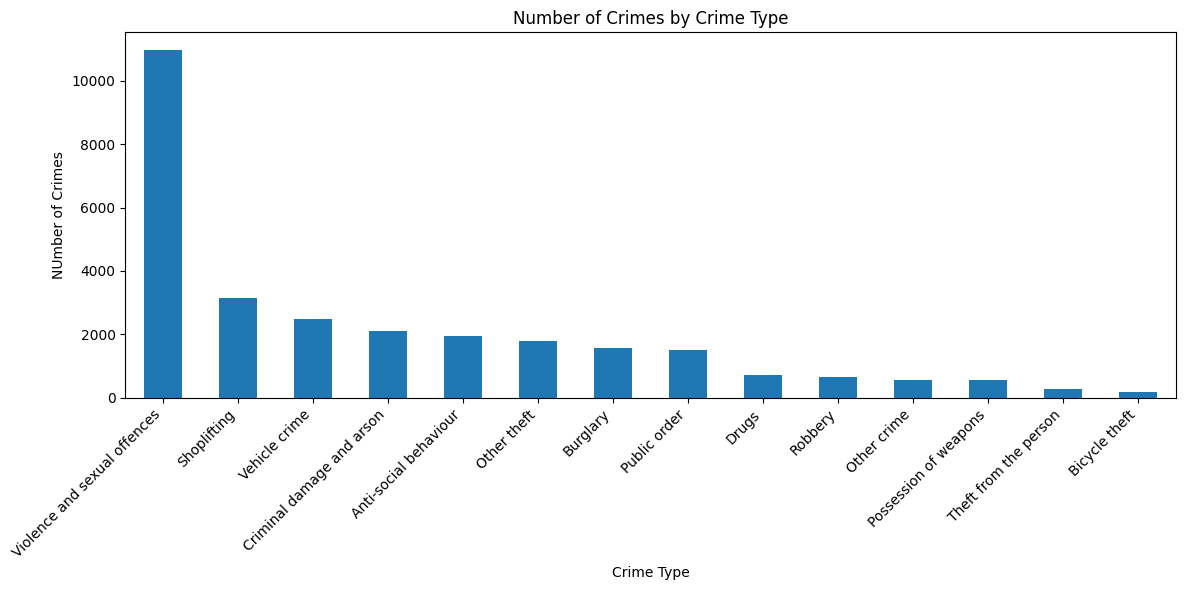

LSOA_Name
Birmingham 138A       443
Birmingham 050F       199
Birmingham 135C       195
Coventry 031F         181
Walsall 030A          173
Coventry 031E         167
Birmingham 050E       150
Wolverhampton 020H    147
Birmingham 136B       134
Wolverhampton 020G    125
Name: count, dtype: int64

In [33]:
# Exploratory Data Analysis
#Question 1: What are the most common types of crime?
crime_counts = df["Crime_Type"].value_counts()
crime_counts
crime_counts.plot(kind="bar", figsize=(12,6))
# Visualization
import matplotlib.pyplot as plt

plt.title("Number of Crimes by Crime Type")
plt.xlabel("Crime Type")
plt.ylabel("NUmber of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Analysis Question 2: Which locations recorded the highest number of crimes?
top_locations = df["Location"].value_counts().head(10)
top_locations

# Analysis Question 3: Which LSOA (neighbourhood) experienced the highest crime rate?
top_lsoa = df["LSOA_Name"].value_counts().head(10)
top_lsoa


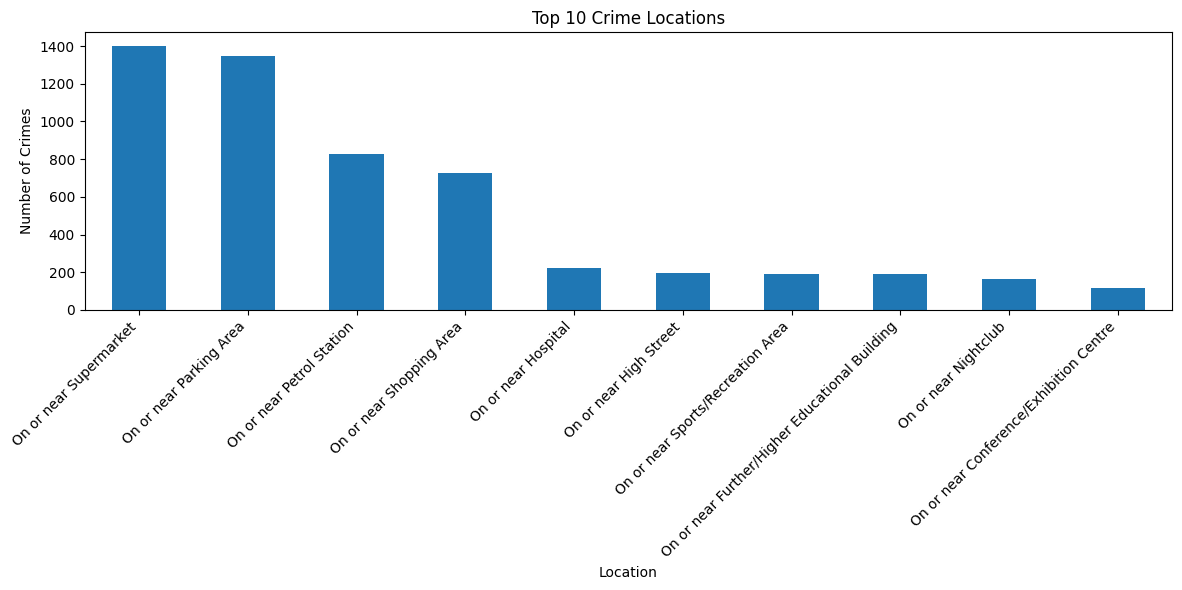

In [28]:
# Analysis Question 4: Which locations experienced the most crimes?
top_locations = df["Location"].value_counts().head(10)
top_locations

# Visualizations
top_locations.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 Crime Locations")
plt.xlabel("Location")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

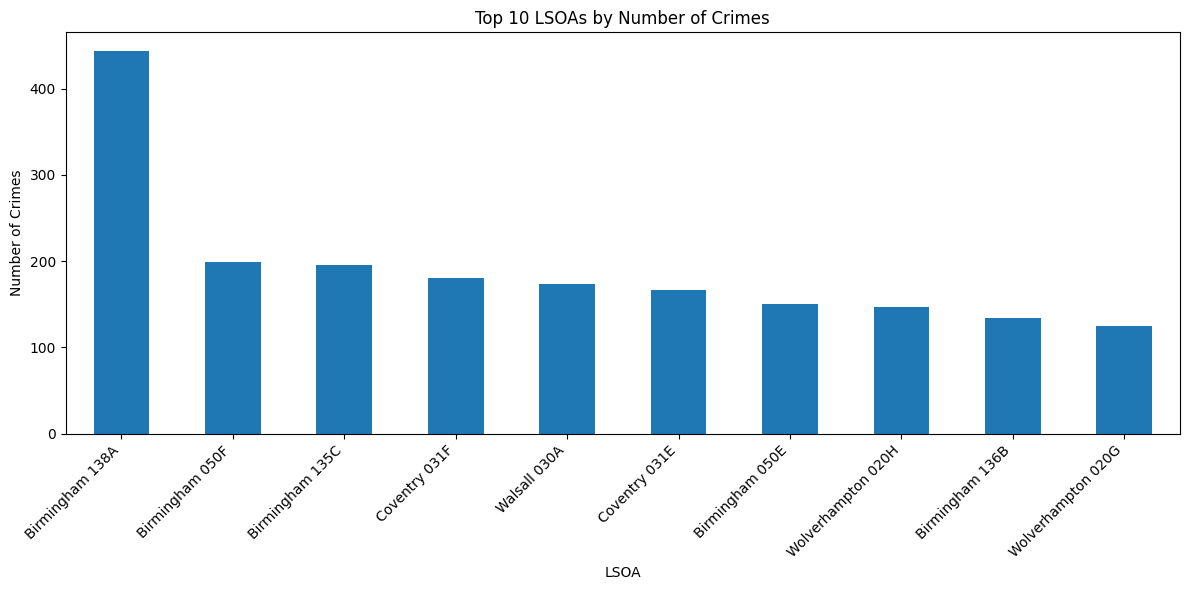

In [30]:
# Analysis Question 5: Which LSOA (neighbourhood) recorded the highest number of crimes?
top_lsoa = df["LSOA_Name"].value_counts().head(10)
top_lsoa

# Visualizations
top_lsoa.plot(kind="bar", figsize=(12,6))

plt.title("Top 10 LSOAs by Number of Crimes")
plt.xlabel("LSOA")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

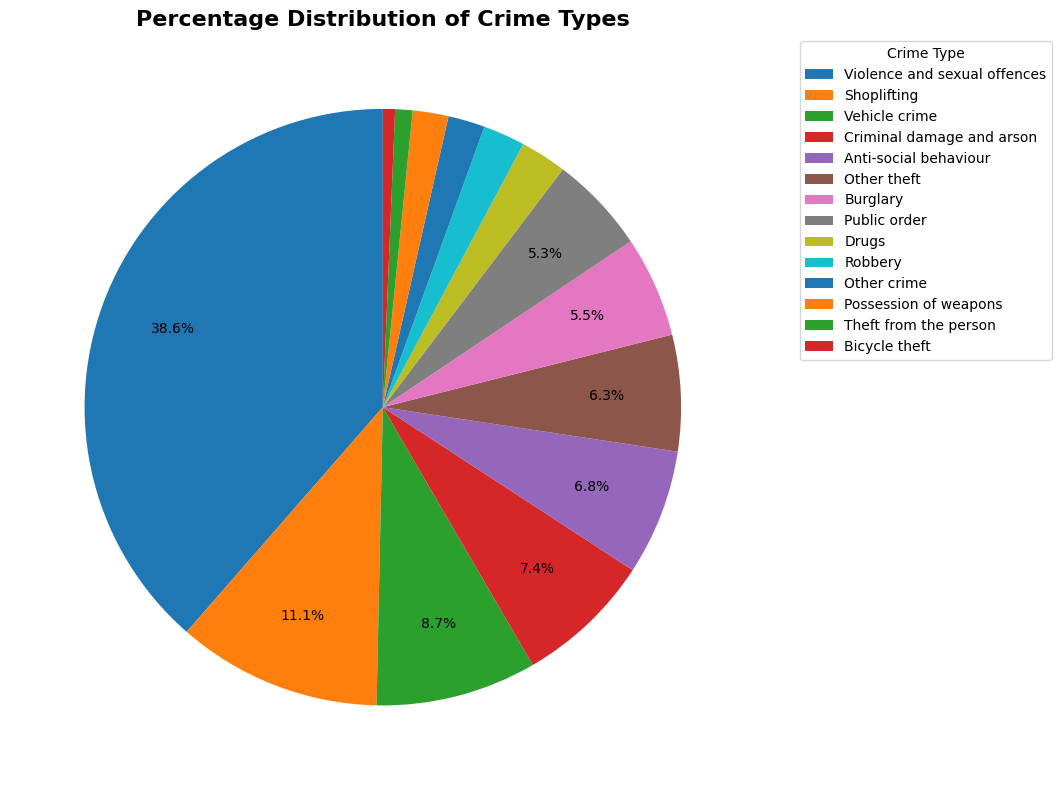

In [ ]:
# Visualization for Analysis Question 6

import matplotlib.pyplot as plt

def autopct_format(pct):
    return f"{pct:.1f}%" if pct >= 3 else ""

plt.figure(figsize=(10, 8))

crime_percent.plot(
    kind="pie",
    labels=None,               
    autopct=autopct_format,    
    startangle=90,
    pctdistance=0.75
)

plt.title("Percentage Distribution of Crime Types",
          fontsize=16,
          fontweight="bold")

plt.legend(
    crime_percent.index,
    title="Crime Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.ylabel("")
plt.tight_layout()

plt.show()

In [ ]:
# Analysis Question 7: What are the most common crime outcomes?
df["Last_Outcome_Category"].value_counts()

Last_Outcome_Category
Under investigation                              11548
Unable to prosecute suspect                       7813
Investigation complete; no suspect identified     5562
Unknown                                           1938
Awaiting court outcome                             873
Action to be taken by another organisation         355
Local resolution                                   259
Offender given a caution                            95
Formal action is not in the public interest          1
Name: count, dtype: int64

In [26]:
#Analysis Question 8: Is there a relationship between crime type and crime outcome?
pd.crosstab(df["Crime_Type"], df["Last_Outcome_Category"])

Last_Outcome_Category,Action to be taken by another organisation,Awaiting court outcome,Formal action is not in the public interest,Investigation complete; no suspect identified,Local resolution,Offender given a caution,Unable to prosecute suspect,Under investigation,Unknown
Crime_Type,,,,,,,,,
Anti-social behaviour,0,0,0,0,0,0,0,0,1938
Bicycle theft,0,4,0,86,0,0,30,67,0
Burglary,1,38,0,682,1,0,120,715,0
Criminal damage and arson,0,51,0,734,16,11,499,798,0
Drugs,0,73,0,19,133,8,40,439,0
Other crime,11,35,0,42,3,0,190,286,0
Other theft,0,11,0,677,6,2,379,716,0
Possession of weapons,1,84,0,70,2,5,93,296,0
Public order,2,67,1,237,11,2,513,677,0


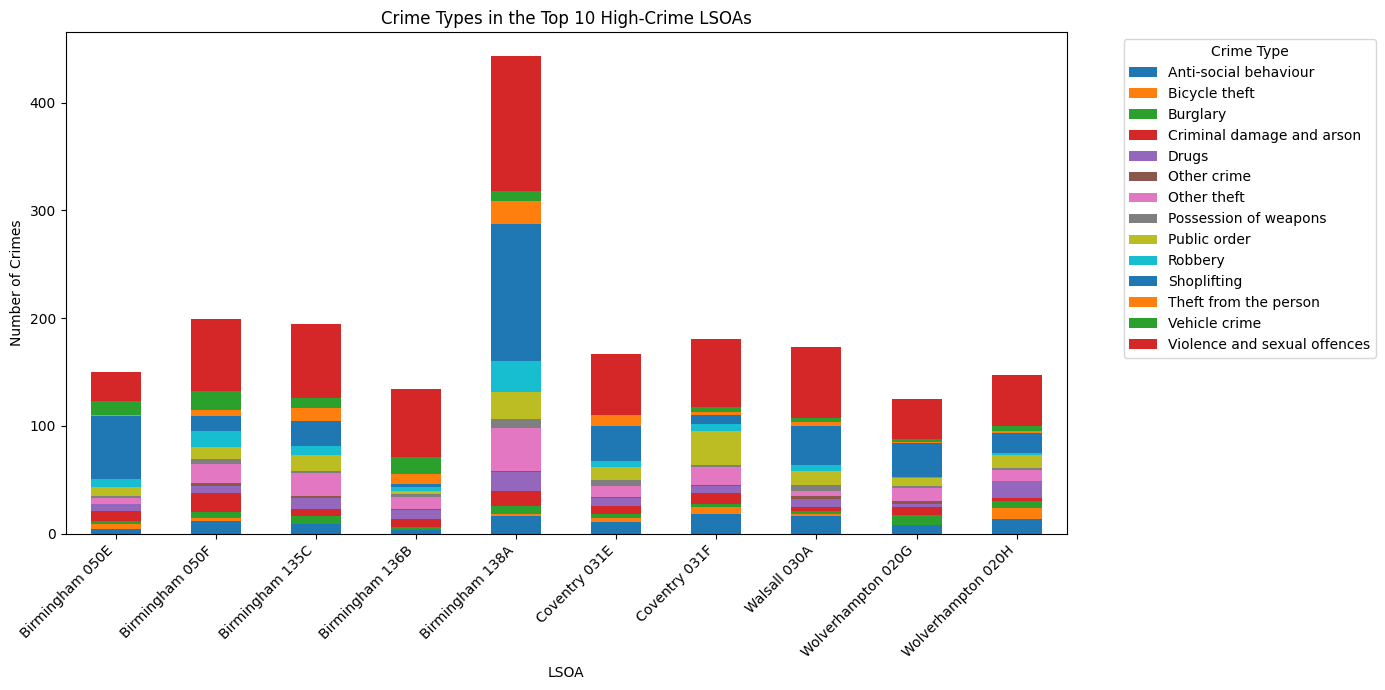

In [35]:
# Analysis Question 9: Which crime types are most common in the top 10 high-crime neighbourhoods (LSOAs)?
# Find the top 10 LSOAs with the most crimes
top_lsoa = df["LSOA_Name"].value_counts().head(10).index

# Filter the dataset to only those LSOAs
top_lsoa_df = df[df["LSOA_Name"].isin(top_lsoa)]

# Count crime types within those LSOAs
crime_lsoa = pd.crosstab(top_lsoa_df["LSOA_Name"], top_lsoa_df["Crime_Type"])

crime_lsoa
crime_lsoa.plot(kind="bar", stacked=True, figsize=(14,7))

plt.title("Crime Types in the Top 10 High-Crime LSOAs")
plt.xlabel("LSOA")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45, ha="right")

plt.legend(
    title="Crime Type",
    bbox_to_anchor=(1.05,1),
    loc="upper left"
)
plt.tight_layout()

plt.show()

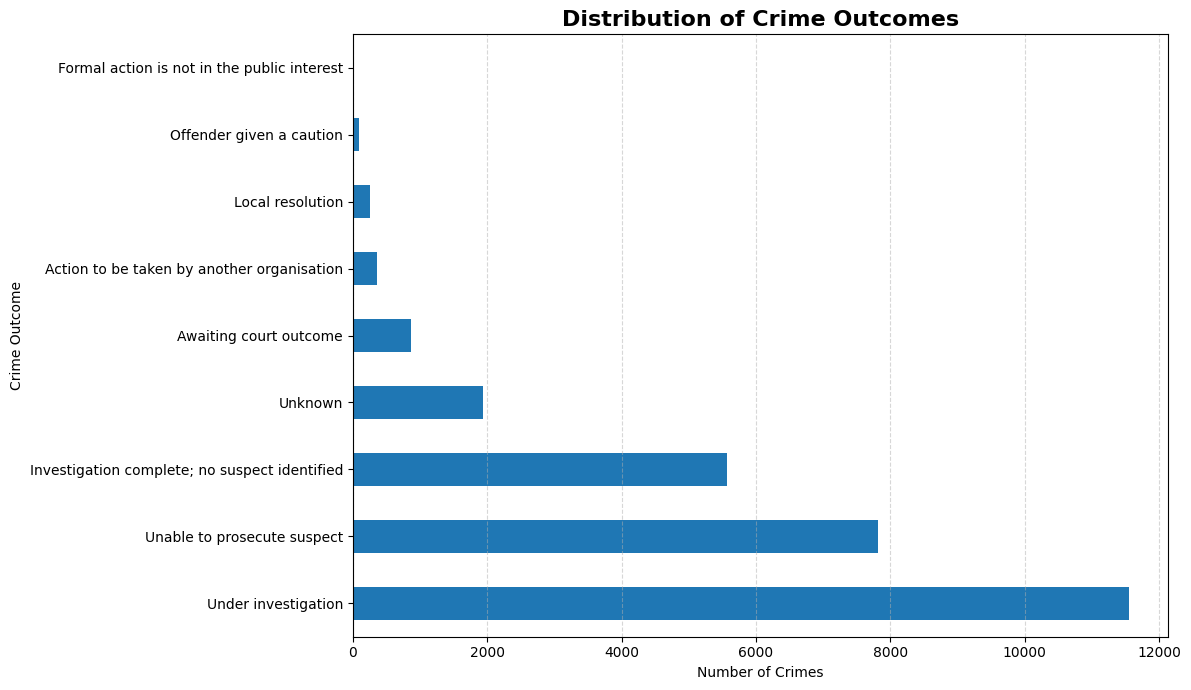

In [41]:
#Analysis Question 10: What proportion of crimes resulted in no further action?
plt.figure(figsize=(12, 7))

outcomes.plot(kind="barh")

plt.title("Distribution of Crime Outcomes", fontsize=16, fontweight="bold")
plt.xlabel("Number of Crimes")
plt.ylabel("Crime Outcome")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()